# PM2.5 Forecasting Using SARIMAX with NO₂

This notebook implements a SARIMAX time-series forecasting model to predict PM2.5 concentrations. Nitrogen dioxide (NO₂) is included as an exogenous variable to evaluate whether secondary pollutants improve PM2.5 prediction accuracy.

## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Load PM2.5 and NO₂ Data

In [4]:
pm25 = pd.read_csv("../../data/validated/PM25_cityday.csv")
no2  = pd.read_csv("../../data/validated/NO2_cityday.csv")

## Data Preparation

In [5]:
pm25["Date"] = pd.to_datetime(pm25["Date"])
no2["Date"] = pd.to_datetime(no2["Date"])

df = pd.merge(
    pm25,
    no2[["City","Date","NO2_daily"]],
    on=["City","Date"],
    how="left"
)

df = df.rename(columns={
    "PM25_daily":"PM25",
    "NO2_daily":"NO2"
})

## Select One City

In [6]:
city_df = df[df["City"]=="Toronto"].copy()

city_df = city_df.sort_values("Date")
city_df = city_df.set_index("Date")

city_df = city_df.asfreq("D")

## Train-Test Split

In [12]:
train = city_df.loc[:'2022-12-31']
test = city_df.loc['2023-01-01':]

## Define Variables

In [13]:
y_train = train["PM25"]
y_test = test["PM25"]

exog_train = train[["NO2"]]
exog_test = test[["NO2"]]


## Fit SARIMAX Model

In [14]:
model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

## Forecast

In [15]:
forecast = model_fit.predict(
    start=y_test.index[0],
    end=y_test.index[-1],
    exog=exog_test
)

## Evaluate Model

In [16]:
rmse = np.sqrt(mean_squared_error(y_test, forecast))
mae  = mean_absolute_error(y_test, forecast)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 6.980748565836463
MAE: 3.8628841727776875


The SARIMAX model achieved an RMSE of 6.98 and an MAE of 3.86, showing that it provides a reasonably accurate forecast of daily PM2.5 levels. The results suggest that NO₂ contributes useful explanatory power in predicting PM2.5 concentrations.

## Forecast Visualization

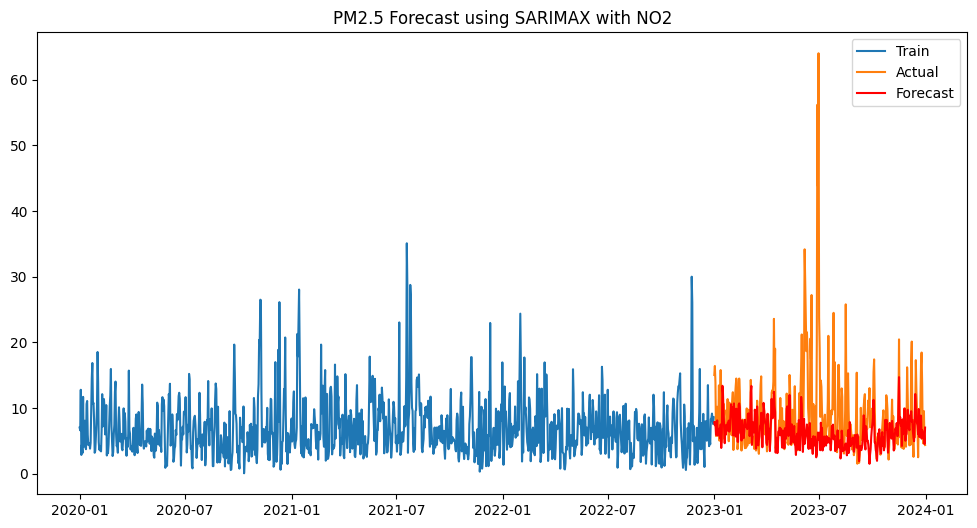

In [17]:
plt.figure(figsize=(12,6))

plt.plot(train.index, y_train, label="Train")
plt.plot(test.index, y_test, label="Actual")
plt.plot(test.index, forecast, label="Forecast", color="red")

plt.title("PM2.5 Forecast using SARIMAX with NO2")
plt.legend()
plt.show()

The forecast generally follows the actual PM2.5 trend, indicating that the model captures the main temporal pattern well. Some differences during peak periods suggest that extreme pollution events are harder to predict accurately.